# 03 Feature Engineering

Validacion del contrato final de features y del preprocesador reusable definido en `src/features/build_features.py`, partiendo de una muestra directa de la OBT ya materializada en Snowflake. La OBT es el resultado de STAGING con todas las reglas de limpieza y las derivadas deterministicas aplicadas por pushdown SQL. En esta etapa la pregunta ya no es que filas descartar, sino que columnas seguras y derivadas deterministicas deben sobrevivir hasta modelado y serving.

## Objetivo del notebook

Este notebook documenta que el modelo trabaja con un conjunto **pequeno, interpretable, multi-flota y libre de leakage**, y que cualquier transformacion adicional se aplica dentro de un pipeline reproducible alineado con la OBT y la API.

## Secuencia metodologica

1. tomar una muestra de la OBT (`ANALYTICS.OBT_TRIPS_DEV`) ya limpia y con features derivadas
2. separar de forma explicita las columnas diagnosticas de las columnas aptas para modelado
3. construir el frame final de features seguras
4. verificar derivadas temporales, variables categoricas y preprocesamiento reusable

## Decision de diseno

En esta fase no se agregan features complejas que puedan introducir leakage o depender de fuentes externas no estabilizadas. Se privilegia un contrato claro y defendible frente a la rubrica: features simples, seguras, compatibles con `yellow` y `green`, y consistentes con serving.

La frontera metodologica es explicita: las derivadas documentadas aqui son deterministicas y no aprenden parametros desde `validation` o `test`. Si mas adelante se incorpora alguna transformacion ajustada, su fitting debe hacerse exclusivamente sobre `train`.


In [3]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / 'src').exists() and (PROJECT_ROOT.parent / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('PROJECT_ROOT =', PROJECT_ROOT)


PROJECT_ROOT = /home/pabseb/DataMining/final-project/price-prediction-ml-end-to-end


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.data.ingestion import balanced_raw_sample_sql, fetch_sample
from src.features.build_features import (
    CATEGORICAL_FEATURES, DISTANCE_COLUMN, LEAKAGE_COLUMNS, MODEL_FEATURE_COLUMNS,
    NUMERIC_FEATURES, RAW_FEATURE_COLUMNS, TARGET_COLUMN,
    build_candidate_modeling_frame, get_feature_pipeline,
    normalize_raw_taxi_frame, prepare_feature_frame, split_features_target,
)
from src.utils.config import get_settings

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)
settings = get_settings()

# Intentar muestrear desde la OBT materializada.
# Si la OBT no existe aun (transform pendiente), cae a RAW + cleaning en memoria.
_obt_available = False
try:
    obt_df = fetch_sample(
        f"SELECT * FROM {settings.obt_table}",
        limit=settings.eda_sample_limit,
        sample_seed=settings.eda_sample_seed,
        settings=settings,
    )
    if not obt_df.empty:
        _obt_available = True
        modeling_df = obt_df.loc[:, RAW_FEATURE_COLUMNS + [TARGET_COLUMN]].copy()
        print(f"[OBT] Muestra cargada desde {settings.obt_table}")
    else:
        print("[OBT] La OBT existe pero esta vacia. Usando RAW como fallback.")
except Exception as _e:
    print(f"[FALLBACK] OBT no disponible ({_e.__class__.__name__}: {_e})")
    print("[FALLBACK] Usando RAW + cleaning en memoria mientras el transform finaliza.")
    _raw = fetch_sample(
        balanced_raw_sample_sql(settings, limit=8000, sample_seed=settings.eda_sample_seed),
        limit=8000,
        sample_seed=settings.eda_sample_seed,
        settings=settings,
    )
    _candidate = build_candidate_modeling_frame(
        _raw, start_date=settings.data_start_date, end_date=settings.data_end_date,
    )
    modeling_df = _candidate.loc[:, RAW_FEATURE_COLUMNS + [TARGET_COLUMN]].copy()
    print("[FALLBACK] Una vez que el transform termine, re-ejecuta esta celda para usar la OBT.")

assert not modeling_df.empty, "modeling_df esta vacio — revisa conexion a Snowflake."
print("fuente     =", "OBT materializada" if _obt_available else "RAW + cleaning en memoria")
print("shape      =", modeling_df.shape)
print("trip_types =")
print(modeling_df['trip_type'].value_counts(dropna=False).sort_index())
modeling_df.head()


[OBT] Muestra cargada desde DM_FINAL_PROJECT.ANALYTICS.OBT_TRIPS_DEV
fuente     = OBT materializada
shape      = (100000, 9)
trip_types =
trip_type
green      7777
yellow    92223
Name: count, dtype: int64


,pickup_datetime,passenger_count,estimated_distance,pickup_location_id,dropoff_location_id,vendor_id,ratecode_id,trip_type,fare_amount
0,2025-11-11 17:00:57,1,0.89,163,237,2,1,yellow,10.7
1,2015-04-25 13:08:00,1,0.30,237,237,1,1,yellow,4.0
2,2018-06-30 15:27:43,1,1.21,246,234,2,1,yellow,6.5
3,2015-04-17 00:06:33,1,2.30,263,239,1,1,yellow,9.0
4,2023-09-07 23:47:02,1,4.34,114,141,2,1,yellow,21.2


In [5]:
X_raw, y = split_features_target(modeling_df)
X_prepared = prepare_feature_frame(X_raw)
print('raw feature frame =', X_raw.shape)
print('prepared feature frame =', X_prepared.shape)
X_prepared.head()


raw feature frame = (100000, 8)
prepared feature frame = (100000, 16)


,trip_type,pickup_hour,pickup_dayofweek,pickup_month,is_weekend,is_rush_hour,is_night,passenger_count,estimated_distance,log_estimated_distance,pickup_location_id,dropoff_location_id,vendor_id,ratecode_id,route_id,same_zone
0,yellow,17,1,11,0,1,0,1,0.89,0.636577,163,237,2,1,163_237,0
1,yellow,13,5,4,1,0,0,1,0.30,0.262364,237,237,1,1,237_237,1
2,yellow,15,5,6,1,0,0,1,1.21,0.792993,246,234,2,1,246_234,0
3,yellow,0,4,4,0,0,1,1,2.30,1.193922,263,239,1,1,263_239,0
4,yellow,23,3,9,0,0,1,1,4.34,1.675226,114,141,2,1,114_141,0


In [6]:
missing_model_cols = sorted(set(MODEL_FEATURE_COLUMNS).difference(X_prepared.columns))
assert not missing_model_cols, f'Faltan columnas de modelado: {missing_model_cols}'
role_map = {
    'trip_type': 'categorical fleet',
    'pickup_hour': 'numeric temporal',
    'pickup_dayofweek': 'numeric temporal',
    'pickup_month': 'numeric temporal',
    'is_weekend': 'numeric temporal',
    'is_rush_hour': 'numeric temporal',
    'is_night': 'numeric temporal',
    'passenger_count': 'numeric trip',
    DISTANCE_COLUMN: 'numeric trip',
    'log_estimated_distance': 'numeric trip',
    'route_id': 'categorical route',
    'same_zone': 'categorical route',
    'pickup_location_id': 'categorical location',
    'dropoff_location_id': 'categorical location',
    'vendor_id': 'categorical operator',
    'ratecode_id': 'categorical operator',
}
feature_contract = pd.DataFrame({
    'feature': MODEL_FEATURE_COLUMNS,
    'role': [role_map[name] for name in MODEL_FEATURE_COLUMNS],
})
feature_contract

# Verificacion anti-leakage: ninguna columna prohibida debe estar en el input del modelo
leakage_in_model = sorted(set(LEAKAGE_COLUMNS).intersection(set(X_prepared.columns)))
assert not leakage_in_model, f'LEAKAGE DETECTADO: {leakage_in_model}'
print('Verificacion anti-leakage: OK — ninguna columna de leakage en el input del modelo')
feature_contract


Verificacion anti-leakage: OK — ninguna columna de leakage en el input del modelo


,feature,role
0,trip_type,categorical fleet
1,pickup_hour,numeric temporal
2,pickup_dayofweek,numeric temporal
3,pickup_month,numeric temporal
4,is_weekend,numeric temporal
5,is_rush_hour,numeric temporal
6,is_night,numeric temporal
7,passenger_count,numeric trip
8,estimated_distance,numeric trip
9,log_estimated_distance,numeric trip


In [7]:
X_prepared[NUMERIC_FEATURES].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T


,count,mean,std,min,1%,5%,50%,95%,99%,max
pickup_hour,100000.0,13.81353,6.157839,0.0,0.0,1.0,15.0,22.0,23.0,23.0
pickup_dayofweek,100000.0,3.02516,1.947025,0.0,0.0,0.0,3.0,6.0,6.0,6.0
pickup_month,100000.0,6.33439,3.486952,1.0,1.0,1.0,6.0,12.0,12.0,12.0
is_weekend,100000.0,0.28034,0.449168,0.0,0.0,0.0,0.0,1.0,1.0,1.0
is_rush_hour,100000.0,0.36081,0.480238,0.0,0.0,0.0,0.0,1.0,1.0,1.0
is_night,100000.0,0.19831,0.398729,0.0,0.0,0.0,0.0,1.0,1.0,1.0
passenger_count,100000.0,1.56043,1.186989,1.0,1.0,1.0,1.0,5.0,6.0,6.0
estimated_distance,100000.0,3.073083,3.869476,0.01,0.3,0.5,1.7,11.18,19.18,113.81
log_estimated_distance,100000.0,1.155951,0.62898,0.00995,0.262364,0.405465,0.993252,2.499795,3.004692,4.743279
same_zone,100000.0,0.06121,0.239716,0.0,0.0,0.0,0.0,1.0,1.0,1.0


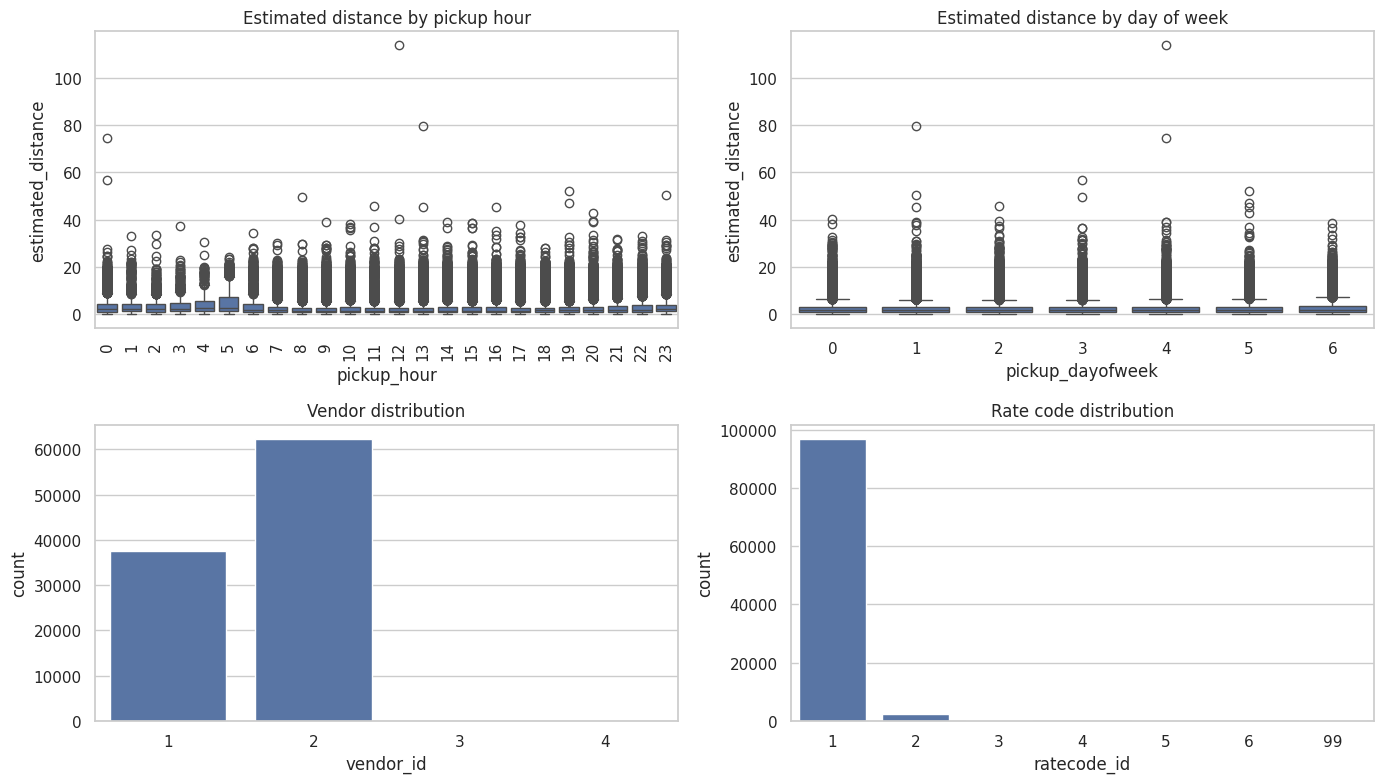

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
sns.boxplot(data=X_prepared, x='pickup_hour', y=DISTANCE_COLUMN, ax=axes[0, 0])
axes[0, 0].set_title('Estimated distance by pickup hour')
axes[0, 0].tick_params(axis='x', rotation=90)
sns.boxplot(data=X_prepared, x='pickup_dayofweek', y=DISTANCE_COLUMN, ax=axes[0, 1])
axes[0, 1].set_title('Estimated distance by day of week')
sns.countplot(data=X_prepared, x='vendor_id', ax=axes[1, 0])
axes[1, 0].set_title('Vendor distribution')
sns.countplot(data=X_prepared, x='ratecode_id', ax=axes[1, 1])
axes[1, 1].set_title('Rate code distribution')
plt.tight_layout()


fare_amount                estimated_distance                \
                 mean median     std               mean median    std   
trip_type                                                               
green          12.657    9.5   9.894              2.970   1.92  3.118   
yellow         13.956   10.0  12.598              3.082   1.70  3.926   

          passenger_count                
                     mean median    std  
trip_type                                
green               1.357    1.0  1.027  
yellow              1.578    1.0  1.198

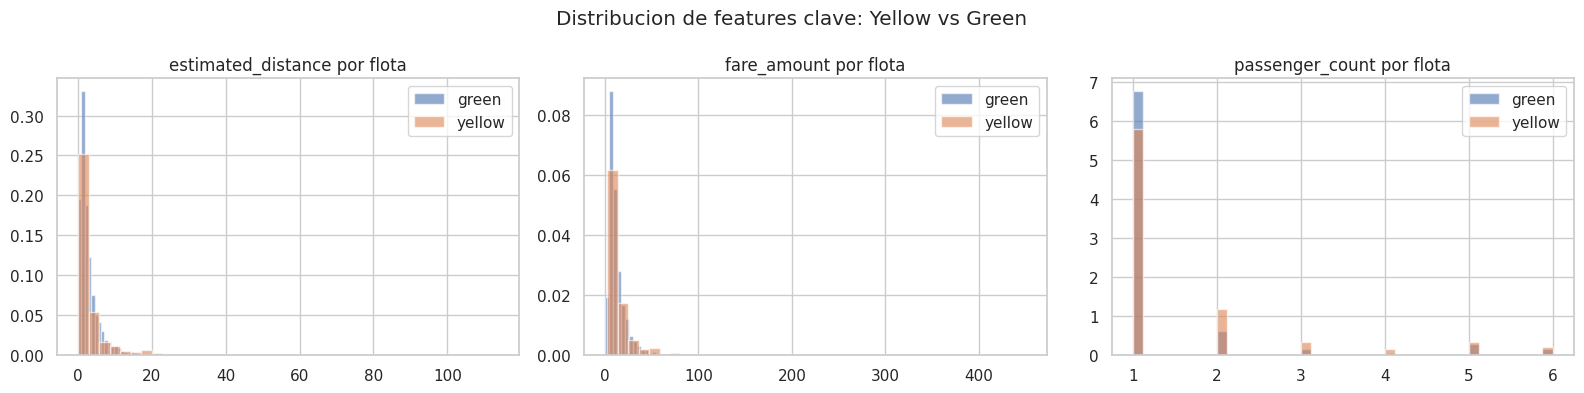

In [9]:
# Comparativa yellow vs green en features numericas clave
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, [DISTANCE_COLUMN, 'fare_amount', 'passenger_count']):
    for tt, grp in modeling_df.groupby('trip_type'):
        grp[col].hist(bins=40, alpha=0.6, label=tt, ax=ax, density=True)
    ax.set_title(f'{col} por flota')
    ax.legend()
plt.suptitle('Distribucion de features clave: Yellow vs Green')
plt.tight_layout()

# Estadisticas descriptivas por flota
modeling_df.groupby('trip_type')[[TARGET_COLUMN, DISTANCE_COLUMN, 'passenger_count']].agg(['mean','median','std']).round(3)


In [10]:
pipeline = get_feature_pipeline()
X_transformed = pipeline.fit_transform(X_raw, y)
print('numeric features =', NUMERIC_FEATURES)
print('categorical features =', CATEGORICAL_FEATURES)
print('transformed shape =', X_transformed.shape)


numeric features = ['pickup_hour', 'pickup_dayofweek', 'pickup_month', 'is_weekend', 'is_rush_hour', 'is_night', 'passenger_count', 'estimated_distance', 'log_estimated_distance', 'same_zone']
categorical features = ['trip_type', 'pickup_location_id', 'dropoff_location_id', 'vendor_id', 'ratecode_id', 'route_id']
transformed shape = (100000, 9491)


In [11]:
pd.Series(y).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])


count    100000.000000
mean         13.854697
std          12.413983
min           0.500000
1%            3.500000
5%            4.500000
50%          10.000000
95%          39.000000
99%          63.500000
max         450.000000
Name: fare_amount, dtype: float64

## Conclusiones e interpretacion

- La muestra utilizada puede provenir de la OBT ya materializada en Snowflake (si el transform ya corrio) o de RAW con cleaning en memoria aplicado via `build_candidate_modeling_frame` (si el transform esta pendiente). En ambos casos el contrato de features validado es identico. Cuando el transform este listo, re-ejecutar la celda de carga para usar la OBT como fuente oficial.
- El contrato final queda claramente definido: `trip_type`, `estimated_distance`, zonas, `vendor_id`, `ratecode_id`, `pickup_datetime` y derivadas temporales deterministicas. El total de features semanticas antes del encoding es `16`, lo que mantiene interpretabilidad.
- La verificacion anti-leakage pasa: ninguna columna prohibida (`payment_type`, `tip_amount`, `total_amount`, etc.) entra al frame de modelado. La OBT y el pipeline de Python estan alineados en este punto.
- El alias `trip_distance` fue removido de la OBT en la version final del contrato. Solo existe `estimated_distance` como nombre oficial del proxy de distancia historica.
- La comparativa yellow vs green confirma que ambas flotas comparten el mismo contrato de features pero pueden mostrar distribuciones distintas en distancia y fare. Esto justifica preservar `trip_type` como feature de modelado.
- El preprocesador reusable del pipeline sklearn es la unica fuente de transformacion para entrenamiento e inferencia. El espacio transformado post-encoding refleja principalmente el one-hot de ubicaciones y categorias, sin leakage adicional.
- Con este notebook queda estable el contrato final de features. Cualquier cambio futuro debe reflejarse simultaneamente en `build_features.py`, en el SQL de la OBT y en la API.
